# 🔧 Feature Engineering
### Diabetes Health Indicators (BRFSS 2015)

This notebook applies and validates the feature engineering pipeline in `src/features.py`, derived from the EDA findings in `01_eda.ipynb`:

- **BMI outlier capping** (extreme values only, ~0.7% of rows)
- **BMI Category** — WHO bands (Underweight / Normal / Overweight / Obese)
- **Lifestyle Score** — composite of PhysActivity, Fruits, Veggies, non-Smoker, non-HvyAlcoholConsump (0-5)
- **Comorbidity Score** — count of HighBP, HighChol, Stroke, HeartDiseaseorAttack (0-4)
- **Stratified train/val/test split**, preserving the 84/2/14 class ratio

Output: a processed dataset + split files saved to `data/processed/` for `03_modeling.ipynb`.

---
## Table of Contents
1. [Setup & Load Raw Data](#1)
2. [BMI Outlier Capping](#2)
3. [BMI Category](#3)
4. [Lifestyle Score](#4)
5. [Comorbidity Score](#5)
6. [Final Feature Set Overview](#6)
7. [Stratified Train/Val/Test Split](#7)
8. [Save Processed Data](#8)


<a id="1"></a>
## 1 | Setup & Load Raw Data

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from src import features as feat

sns.set_theme(style="whitegrid", font_scale=1.05)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.facecolor'] = 'white'

FIG_DIR = Path('../reports/figures')
PROC_DIR = Path('../data/processed')
PROC_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLORS = {0: '#2ecc71', 1: '#f1c40f', 2: '#e74c3c'}
TARGET_LABELS = feat.TARGET_LABELS
TARGET_ORDER = [0, 1, 2]

df = feat.load_raw('../data/diabetes_012_health_indicators_BRFSS2015.csv')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns")
df.head()

Loaded 253,680 rows and 22 columns


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,...,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,...,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,...,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


<a id="2"></a>
## 2 | BMI Outlier Capping

The EDA showed BMI ranges from 12 to 98, with 99.5th percentile at 55. We cap at Q3 + 3×IQR (≈52, the "extreme outlier" convention) — this affects only ~0.7% of rows and tames a handful of likely data-entry extremes (BMI > 70) without touching the genuinely informative obese range.

Upper cap: 52.0
Rows affected: 1,707 (0.67%)


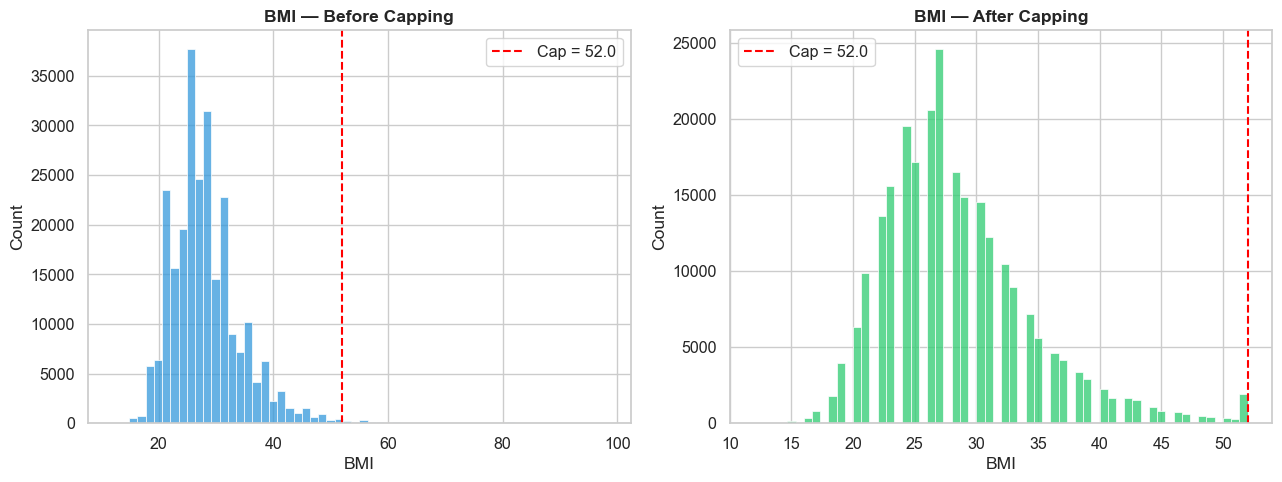

In [2]:
df_capped, bmi_upper = feat.cap_bmi_outliers(df)
n_affected = (df['BMI'] > bmi_upper).sum()

print(f"Upper cap: {bmi_upper}")
print(f"Rows affected: {n_affected:,} ({n_affected/len(df)*100:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df['BMI'], bins=60, ax=axes[0], color='#3498db')
axes[0].axvline(bmi_upper, color='red', linestyle='--', label=f'Cap = {bmi_upper}')
axes[0].set_title('BMI — Before Capping', fontweight='bold')
axes[0].legend()

sns.histplot(df_capped['BMI'], bins=60, ax=axes[1], color='#2ecc71')
axes[1].axvline(bmi_upper, color='red', linestyle='--', label=f'Cap = {bmi_upper}')
axes[1].set_title('BMI — After Capping', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

<a id="3"></a>
## 3 | BMI Category

WHO bands mapped to an ordinal feature: 0=Underweight, 1=Normal, 2=Overweight, 3=Obese.

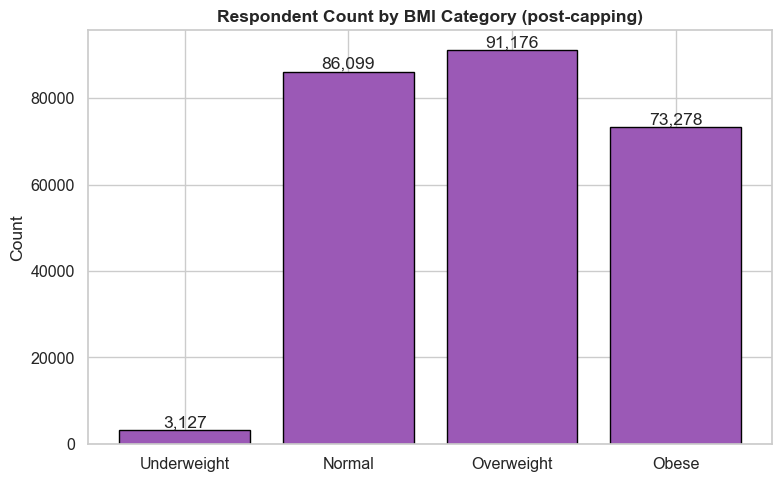

Underweight     3127
Normal         86099
Overweight     91176
Obese          73278
Name: count, dtype: int64

In [3]:
df_eng = feat.add_bmi_category(df_capped)

cat_counts = df_eng['BMICategory'].value_counts().sort_index()
cat_counts.index = feat.BMI_CATEGORY_LABELS

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(cat_counts.index, cat_counts.values, color='#9b59b6', edgecolor='black')
ax.set_title('Respondent Count by BMI Category (post-capping)', fontweight='bold')
ax.set_ylabel('Count')
for i, v in enumerate(cat_counts.values):
    ax.text(i, v, f'{v:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

cat_counts

<a id="4"></a>
## 4 | Lifestyle Score

A composite 0-5 score: +1 each for `PhysActivity`, `Fruits`, `Veggies` (present), and +1 each for **not** `Smoker` / **not** `HvyAlcoholConsump`. Higher = healthier lifestyle. We check whether it shows a clean gradient against diabetes status.

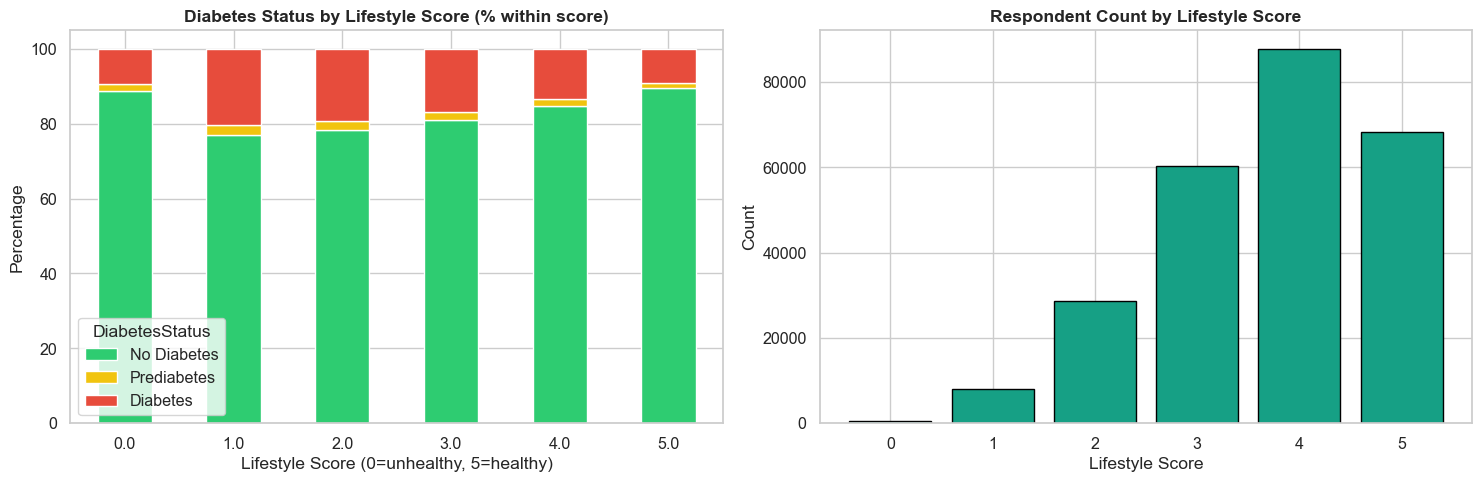

DiabetesStatus,No Diabetes,Prediabetes,Diabetes
LifestyleScore,,,
0.0,88.8,1.8,9.4
1.0,77.1,2.5,20.4
2.0,78.4,2.3,19.3
3.0,81.1,2.1,16.9
4.0,84.9,1.8,13.4
5.0,89.5,1.4,9.1


In [4]:
df_eng = feat.add_lifestyle_score(df_eng)
df_eng['DiabetesStatus'] = df_eng['Diabetes_012'].map(TARGET_LABELS)

life_ct = pd.crosstab(df_eng['LifestyleScore'], df_eng['DiabetesStatus'], normalize='index') * 100
life_ct = life_ct[[TARGET_LABELS[c] for c in TARGET_ORDER]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

life_ct.plot(kind='bar', stacked=True, color=[TARGET_COLORS[c] for c in TARGET_ORDER],
              ax=axes[0], edgecolor='white')
axes[0].set_title('Diabetes Status by Lifestyle Score (% within score)', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Lifestyle Score (0=unhealthy, 5=healthy)')
axes[0].tick_params(axis='x', rotation=0)

life_counts = df_eng['LifestyleScore'].value_counts().sort_index()
axes[1].bar(life_counts.index, life_counts.values, color='#16a085', edgecolor='black')
axes[1].set_title('Respondent Count by Lifestyle Score', fontweight='bold')
axes[1].set_xlabel('Lifestyle Score')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

life_ct.round(1)

> **Observation:** From score 1 to 5, diabetes prevalence decreases monotonically (20.4% → 19.3% → 16.9% → 13.4% → 9.1%) — a clean gradient. Score 0 (9.4%) breaks the pattern, but this group is tiny (489 respondents, 0.2% of data) and by definition 100% heavy-alcohol consumers — and `HvyAlcoholConsump` itself showed a *negative* correlation with diabetes in the EDA (likely an age/selection confound: heavy drinkers in this survey skew younger). So the composite score is informative for the bulk of the population (scores 1-5) but the extreme score-0 group reflects a small, confounded subgroup rather than "very unhealthy = very high risk". Worth flagging — composite scores can mask confounds in their constituent features.

<a id="5"></a>
## 5 | Comorbidity Score

Count (0-4) of `HighBP`, `HighChol`, `Stroke`, `HeartDiseaseorAttack` — the four features with the strongest chi-square effect sizes (rank #1, #4, #9, #5 in the EDA). This summarizes overlapping cardiovascular risk signals into one ordinal feature.

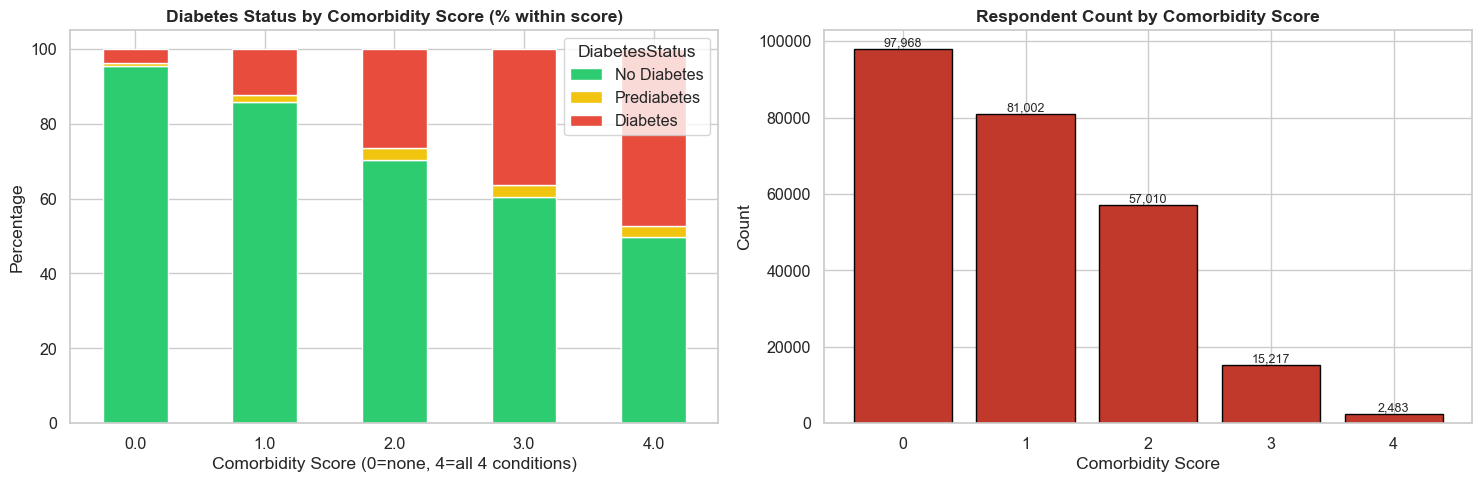

DiabetesStatus,No Diabetes,Prediabetes,Diabetes
ComorbidityScore,,,
0.0,95.5,0.8,3.7
1.0,85.9,1.9,12.2
2.0,70.4,3.1,26.5
3.0,60.5,3.1,36.4
4.0,49.9,2.7,47.4


In [5]:
df_eng = feat.add_comorbidity_score(df_eng)

como_ct = pd.crosstab(df_eng['ComorbidityScore'], df_eng['DiabetesStatus'], normalize='index') * 100
como_ct = como_ct[[TARGET_LABELS[c] for c in TARGET_ORDER]]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

como_ct.plot(kind='bar', stacked=True, color=[TARGET_COLORS[c] for c in TARGET_ORDER],
              ax=axes[0], edgecolor='white')
axes[0].set_title('Diabetes Status by Comorbidity Score (% within score)', fontweight='bold')
axes[0].set_ylabel('Percentage')
axes[0].set_xlabel('Comorbidity Score (0=none, 4=all 4 conditions)')
axes[0].tick_params(axis='x', rotation=0)

como_counts = df_eng['ComorbidityScore'].value_counts().sort_index()
axes[1].bar(como_counts.index, como_counts.values, color='#c0392b', edgecolor='black')
axes[1].set_title('Respondent Count by Comorbidity Score', fontweight='bold')
axes[1].set_xlabel('Comorbidity Score')
axes[1].set_ylabel('Count')
for i, v in zip(como_counts.index, como_counts.values):
    axes[1].text(i, v, f'{v:,}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

como_ct.round(1)

> **Observation:** This is a much cleaner gradient — diabetes prevalence rises from 3.7% (0 comorbidities) to 47.4% (all 4 conditions present), monotonically across all 5 levels, with no confounded subgroup. The Comorbidity Score looks like a strong engineered feature — a 13x difference in prevalence from lowest to highest level.

<a id="6"></a>
## 6 | Final Feature Set Overview

Compare the engineered dataset to the original — 22 original columns + 2 new engineered features (`BMICategory`, `LifestyleScore`, `ComorbidityScore` = 3 new), with `BMI` capped in place.

In [6]:
print(f"Original columns ({df.shape[1]}): {list(df.columns)}\n")
print(f"Engineered columns ({df_eng.shape[1] - 1}): {[c for c in df_eng.columns if c != 'DiabetesStatus']}\n")

new_cols = [c for c in df_eng.columns if c not in df.columns and c != 'DiabetesStatus']
print(f"New engineered features: {new_cols}")

df_eng[['BMI', 'BMICategory', 'LifestyleScore', 'ComorbidityScore', 'Diabetes_012']].describe().T

Original columns (22): ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']

Engineered columns (25): ['Diabetes_012', 'HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income', 'BMICategory', 'LifestyleScore', 'ComorbidityScore']

New engineered features: ['BMICategory', 'LifestyleScore', 'ComorbidityScore']


,count,mean,std,min,25%,50%,75%,max
BMI,253680.0,28.293831,6.109271,12.0,24.0,27.0,31.0,52.0
BMICategory,253680.0,1.924807,0.819704,0.0,1.0,2.0,3.0,3.0
LifestyleScore,253680.0,3.702854,1.089246,0.0,3.0,4.0,5.0,5.0
ComorbidityScore,253680.0,0.987878,0.968921,0.0,0.0,1.0,2.0,4.0
Diabetes_012,253680.0,0.296921,0.698160,0.0,0.0,0.0,0.0,2.0


In [7]:
new_feat_corr = df_eng[['BMICategory', 'LifestyleScore', 'ComorbidityScore', 'Diabetes_012']].corr()['Diabetes_012'].drop('Diabetes_012')
print("Correlation of new engineered features with Diabetes_012:")
print(new_feat_corr.sort_values(ascending=False))
print("\nFor comparison, raw BMI correlation:", df_eng[['BMI','Diabetes_012']].corr().iloc[0,1].round(4))
print("For comparison, raw HighBP correlation:", df_eng[['HighBP','Diabetes_012']].corr().iloc[0,1].round(4))

Correlation of new engineered features with Diabetes_012:
ComorbidityScore    0.321549
BMICategory         0.218808
LifestyleScore     -0.104337
Name: Diabetes_012, dtype: float64

For comparison, raw BMI correlation: 0.2399
For comparison, raw HighBP correlation: 0.2716


> **Result:** `ComorbidityScore` (r=0.32) now **outranks every original feature**, including `GenHlth` (0.30) and `HighBP` (0.27) — the best single linear predictor in the dataset. `BMICategory` (0.22) carries similar signal to raw `BMI` (0.24) but as a 4-level ordinal it may help tree splits. `LifestyleScore` (-0.10) is weaker but stronger than any of its 5 constituent binary features individually. All three engineered features earn a place in the modeling feature set.

<a id="7"></a>
## 7 | Stratified Train/Val/Test Split

Split 70% train / 15% validation / 15% test, stratified on `Diabetes_012` to preserve the 84.2% / 1.8% / 13.9% ratio in every split — critical given the severe class imbalance.

In [8]:
X, y = feat.get_feature_target_split(df_eng.drop(columns=['DiabetesStatus']))

X_train, X_val, X_test, y_train, y_val, y_test = feat.stratified_split(
    X, y, test_size=0.15, val_size=0.15, random_state=42
)

print(f"Train: {X_train.shape[0]:,} rows")
print(f"Val:   {X_val.shape[0]:,} rows")
print(f"Test:  {X_test.shape[0]:,} rows")

split_summary = pd.DataFrame({
    'Full': y.value_counts(normalize=True).sort_index() * 100,
    'Train': y_train.value_counts(normalize=True).sort_index() * 100,
    'Val': y_val.value_counts(normalize=True).sort_index() * 100,
    'Test': y_test.value_counts(normalize=True).sort_index() * 100,
})
split_summary.index = [TARGET_LABELS[i] for i in split_summary.index]
split_summary.round(2)

Train: 177,576 rows
Val:   38,052 rows
Test:  38,052 rows


,Full,Train,Val,Test
No Diabetes,84.24,84.24,84.24,84.24
Prediabetes,1.83,1.83,1.83,1.83
Diabetes,13.93,13.93,13.93,13.93


<a id="8"></a>
## 8 | Save Processed Data

Save the engineered, split datasets to `data/processed/` so `03_modeling.ipynb` can load them directly without re-running feature engineering.

In [9]:
train_df = X_train.copy(); train_df['Diabetes_012'] = y_train
val_df = X_val.copy(); val_df['Diabetes_012'] = y_val
test_df = X_test.copy(); test_df['Diabetes_012'] = y_test

train_df.to_csv(PROC_DIR / 'train.csv', index=False)
val_df.to_csv(PROC_DIR / 'val.csv', index=False)
test_df.to_csv(PROC_DIR / 'test.csv', index=False)

# Also save the full engineered dataset (pre-split) for dashboard EDA reuse
df_eng.drop(columns=['DiabetesStatus']).to_csv(PROC_DIR / 'diabetes_engineered.csv', index=False)

for f in PROC_DIR.iterdir():
    print(f"{f.name}: {f.stat().st_size / 1e6:.2f} MB")

val.csv: 3.79 MB
test.csv: 3.79 MB
diabetes_engineered.csv: 25.27 MB
train.csv: 17.69 MB


---
## Summary

| Step | Result |
|---|---|
| BMI capping | 1,707 rows (0.67%) capped at 52 |
| BMICategory | 4-level ordinal, r=0.22 with target |
| LifestyleScore | 0-5 composite, r=-0.10 (non-monotonic at extreme 0, confounded by HvyAlcoholConsump) |
| ComorbidityScore | 0-4 composite, r=0.32 — **strongest single feature in the dataset** |
| Train/Val/Test | 177,576 / 38,052 / 38,052 rows, class ratios preserved exactly |
| Output | `data/processed/{train,val,test,diabetes_engineered}.csv` |

**Next:** `03_modeling.ipynb` — train and tune Logistic Regression, Random Forest, Gradient Boosting, XGBoost, and LightGBM on `train.csv`, addressing the 84/2/14 class imbalance via class weighting and/or SMOTE, with evaluation on `val.csv` and a final check on `test.csv`.